# STPLS3D End-to-End Pipeline

This notebook orchestrates the full workflow:
1. PLY -> LAS (stretch + tiling + reports)
2. LAS tiles -> tensors + PNG (features/RGB/masks)
3. Training
4. Evaluation on val/test
5. Quick visual checks and metric plots

It calls existing project scripts via subprocess to keep one source of truth.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: [dfs_ephemeral] Credentials propagation unsuccessful

In [2]:
from pathlib import Path
import sys

RUN_ENV = "colab"  # "local" or "colab"

if RUN_ENV == "local":
    PROJECT_ROOT = Path(r"c:\Users\alexe\VSCprojects\lidar-visual-interface")
else:
    PROJECT_ROOT = Path("/content/lidar-visual-interface")  # или ваш путь в Drive

print("PROJECT_ROOT =", PROJECT_ROOT)
print("PYTHON      =", sys.executable)

PROJECT_ROOT = /content/lidar-visual-interface
PYTHON      = /usr/bin/python3


In [8]:
# -------- Configuration --------
CFG = {
    # Input PLY directories (set these if you run PLY->LAS stage)
    'ply_train_dir': PROJECT_ROOT / 'data' / 'stpls3d_ply' / 'train',
    'ply_val_dir': PROJECT_ROOT / 'data' / 'stpls3d_ply' / 'val',
    'ply_test_dir': PROJECT_ROOT / 'data' / 'stpls3d_ply' / 'test',

    # Prepared LAS directories
    'prepared_las_root': PROJECT_ROOT / 'data' / 'stpls3d_prepared',

    # Ready image/tensor datasets
    'ready_root': PROJECT_ROOT / 'data' / 'stpls3d_ready',

    # Training artifacts
    'checkpoint_dir': PROJECT_ROOT / 'checkpoints_notebook',
    'eval_val_dir': PROJECT_ROOT / 'eval_notebook_val',
    'eval_test_dir': PROJECT_ROOT / 'eval_notebook_test',

    # Pipeline params
    'tile_size': 250,
    'target_points_per_tile': 500_000,
    'seed': 42,
    'num_points': 40_000,
    'grid_size': 512,
    'k_nn': 4,
    'knn_eps': 0.1,
    'knn_workers': -1,

    # Training params
    'epochs': 2,
    'batch_size': 2,
    'lr': 1e-3,
    'device': 'auto',
}

# Toggle stages
RUN_PLY_TO_LAS = True
RUN_PREPARE_DATA = True
RUN_TRAIN = True
RUN_EVAL = True

CFG

TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [3]:
def run_cmd(args: list[str], cwd: Path | None = None, check: bool = True) -> int:
    cmd = [str(a) for a in args]
    print('\
$ ' + ' '.join(shlex.quote(c) for c in cmd))
    proc = subprocess.run(cmd, cwd=str(cwd or PROJECT_ROOT), check=False)
    if check and proc.returncode != 0:
        raise RuntimeError(f'Command failed with exit code {proc.returncode}')
    return proc.returncode

def count_files(path: Path, pattern: str) -> int:
    return len(list(path.glob(pattern)))

def show_samples(img_dir: Path, title: str, n: int = 6):
    files = sorted(img_dir.glob('*.png'))[:n]
    if not files:
        print(f'No PNG files in {img_dir}')
        return
    cols = min(3, len(files))
    rows = int(np.ceil(len(files) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, p in zip(axes, files):
        ax.imshow(Image.open(p))
        ax.set_title(p.name)
        ax.axis('off')
    for ax in axes[len(files):]:
        ax.axis('off')
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

## 1) Optional: PLY -> Prepared LAS (train/val/test)

In [9]:
if RUN_PLY_TO_LAS:
    for split, in_dir in [
        ('train', CFG['ply_train_dir']),
        ('val', CFG['ply_val_dir']),
        ('test', CFG['ply_test_dir']),
    ]:
        out_dir = CFG['prepared_las_root'] / split
        run_cmd([
            sys.executable,
            'training/prepare_stpls3d_las.py',
            '--input-dir', in_dir,
            '--output-dir', out_dir,
            '--tile-size', CFG['tile_size'],
            '--target-points-per-tile', CFG['target_points_per_tile'],
            '--seed', CFG['seed'],
        ])
else:
    print('RUN_PLY_TO_LAS=False -> skipped')

$ 'c:\Users\alexe\VSCprojects\lidar-visual-interface\venv\Scripts\python.exe' training/prepare_stpls3d_las.py --input-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_ply\train' --output-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_prepared\train' --tile-size 250 --target-points-per-tile 500000 --seed 42
$ 'c:\Users\alexe\VSCprojects\lidar-visual-interface\venv\Scripts\python.exe' training/prepare_stpls3d_las.py --input-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_ply\val' --output-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_prepared\val' --tile-size 250 --target-points-per-tile 500000 --seed 42
$ 'c:\Users\alexe\VSCprojects\lidar-visual-interface\venv\Scripts\python.exe' training/prepare_stpls3d_las.py --input-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_ply\test' --output-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_prepared\test' --tile-size 250 --ta

## 2) LAS tiles -> tensors + PNG (train/val/test)

In [12]:
if RUN_PREPARE_DATA:
    for split in ["train", "val", "test"]:
        las_tiles_dir = CFG["prepared_las_root"] / split / "tiles_las"
        out_dir = CFG["ready_root"] / split

        print(f"\n[{split}] raw-dir={las_tiles_dir}")
        print("exists:", las_tiles_dir.exists(), "las:", len(list(las_tiles_dir.glob("*.las"))))

        rc = run_cmd([
            sys.executable,
            "-m", "training.prepare_data",
            "--raw-dir", las_tiles_dir,
            "--output-dir", out_dir,
            "--skip-tiling",
            "--num-points", CFG["num_points"],
            "--grid-size", CFG["grid_size"],
            "--k-nn", CFG["k_nn"],
            # временно без параллелизма для диагностики:
            # "--parallel-encode",
            "--knn-workers", 1,
            "--knn-eps", 0.0,
        ], check=False)

        print(f"[{split}] return code = {rc}")
        if rc != 0:
            print(f"[{split}] failed, stop.")
            break
else:
    print("RUN_PREPARE_DATA=False -> skipped")


[train] raw-dir=c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_prepared\train\tiles_las
exists: True las: 27
$ 'c:\Users\alexe\VSCprojects\lidar-visual-interface\venv\Scripts\python.exe' -m training.prepare_data --raw-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_prepared\train\tiles_las' --output-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_ready\train' --skip-tiling --num-points 40000 --grid-size 512 --k-nn 4 --knn-workers 1 --knn-eps 0.0
[train] return code = 0

[val] raw-dir=c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_prepared\val\tiles_las
exists: True las: 9
$ 'c:\Users\alexe\VSCprojects\lidar-visual-interface\venv\Scripts\python.exe' -m training.prepare_data --raw-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_prepared\val\tiles_las' --output-dir 'c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_ready\val' --skip-tiling --num-points 40000 --grid-size 512 --k-nn 4 -

## 3) Quick sanity checks

In [13]:
for split in ['train', 'val', 'test']:
    base = CFG['ready_root'] / split
    print(f'\
[{split}] {base}')
    print('  img_features:', count_files(base / 'img_features', '*.png'))
    print('  img_rgb:     ', count_files(base / 'img_rgb', '*.png'))
    print('  img_class:   ', count_files(base / 'img_class', '*.png'))
    print('  tensors:     ', count_files(base / 'tensors', '*.npy'))

[train] c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_ready\train
  img_features: 27
  img_rgb:      27
  img_class:    27
  tensors:      27
[val] c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_ready\val
  img_features: 9
  img_rgb:      9
  img_class:    9
  tensors:      9
[test] c:\Users\alexe\VSCprojects\lidar-visual-interface\data\stpls3d_ready\test
  img_features: 27
  img_rgb:      27
  img_class:    27
  tensors:      27


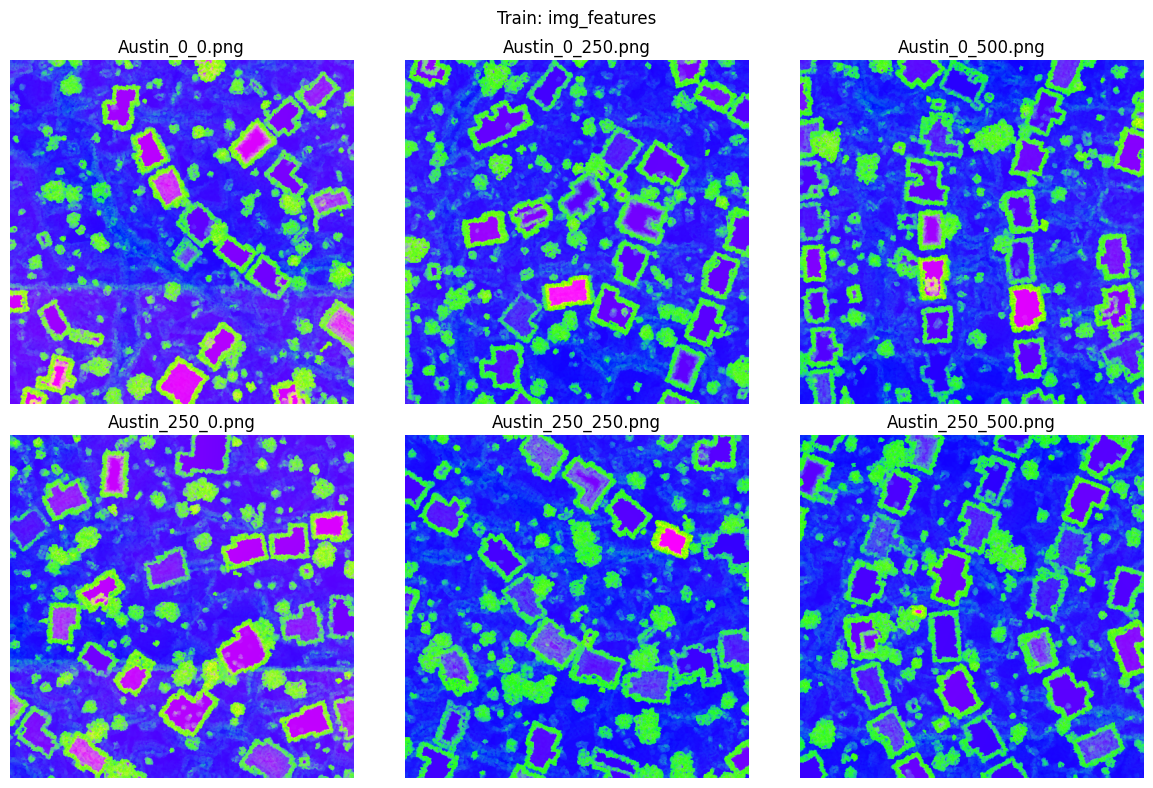

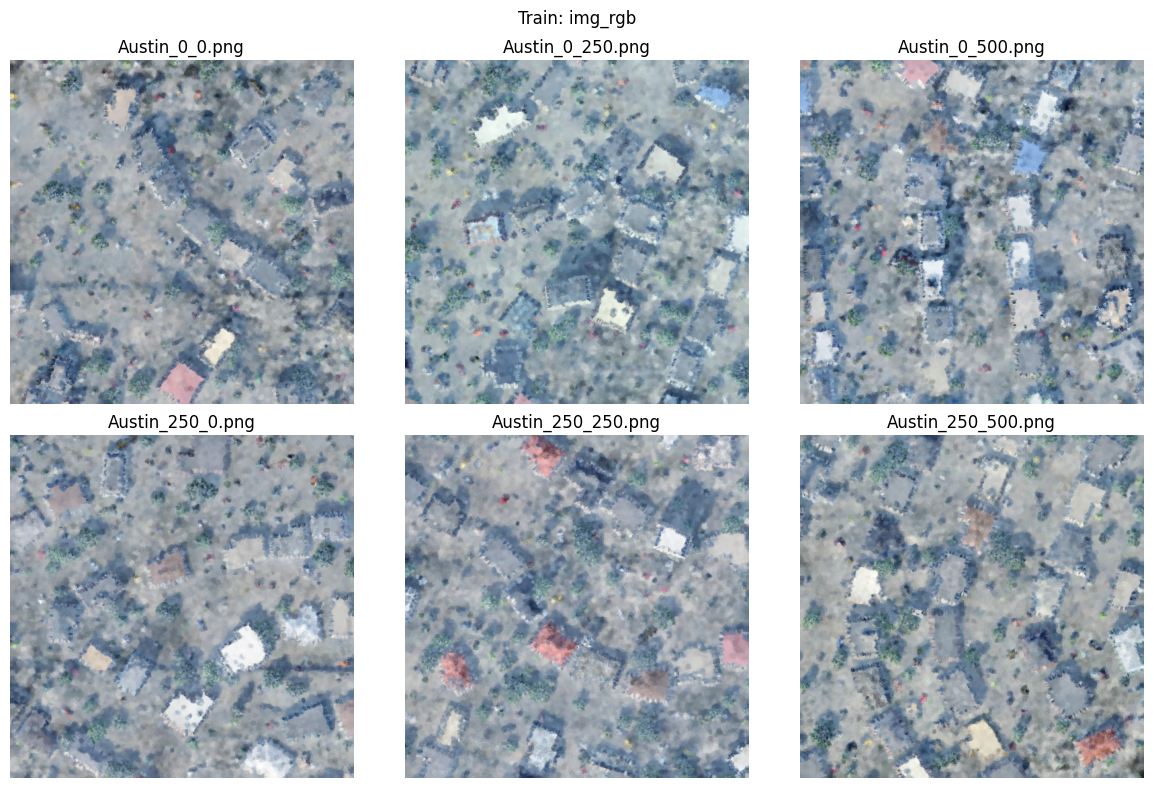

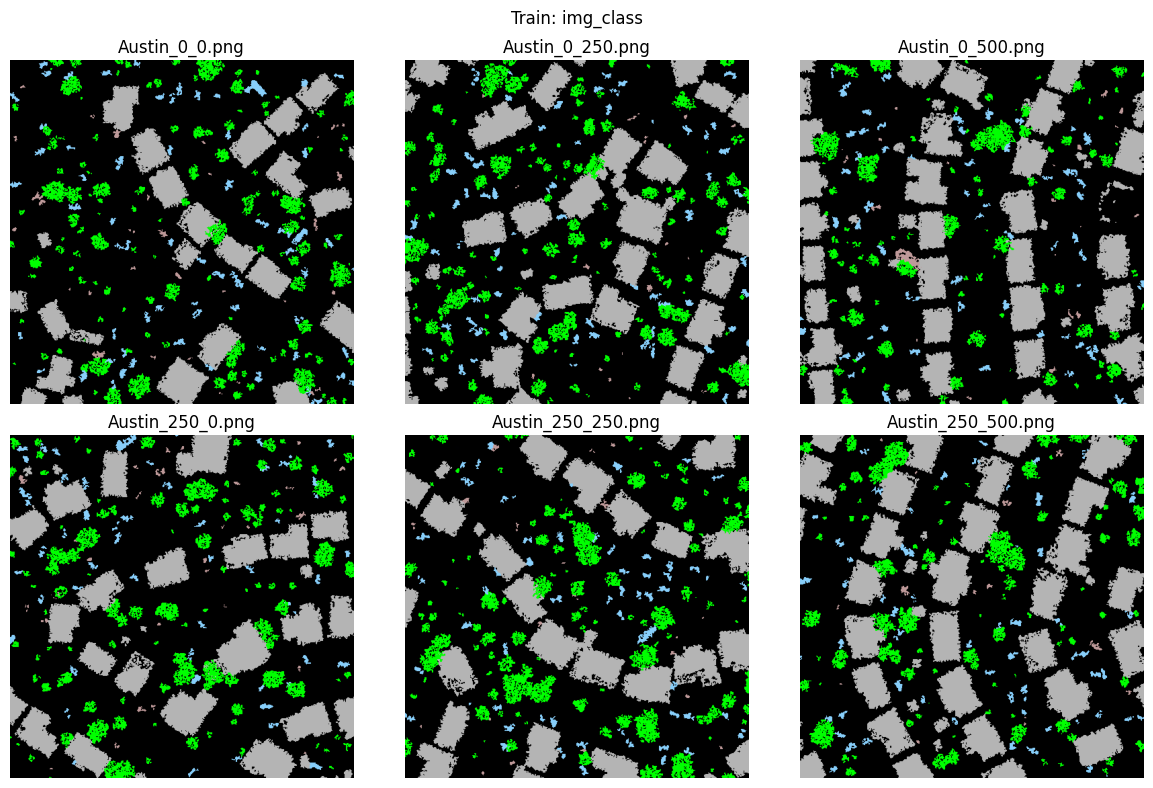

In [14]:
show_samples(CFG['ready_root'] / 'train' / 'img_features', 'Train: img_features')
show_samples(CFG['ready_root'] / 'train' / 'img_rgb', 'Train: img_rgb')
show_samples(CFG['ready_root'] / 'train' / 'img_class', 'Train: img_class')

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## 4) Train

In [2]:
if RUN_TRAIN:
    run_cmd([
        sys.executable,
        '-m',
        'training.train',
        '--features-dir', CFG['ready_root'] / 'train' / 'img_features',
        '--masks-dir', CFG['ready_root'] / 'train' / 'img_class',
        '--epochs', CFG['epochs'],
        '--batch-size', CFG['batch_size'],
        '--lr', CFG['lr'],
        '--device', CFG['device'],
        '--checkpoint-dir', CFG['checkpoint_dir'],
        '--seed', CFG['seed'],
    ])
else:
    print('RUN_TRAIN=False -> skipped')

NameError: name 'RUN_TRAIN' is not defined

In [ ]:
epoch_summary = CFG['checkpoint_dir'] / 'epoch_summary.csv'
if epoch_summary.exists():
    df = pd.read_csv(epoch_summary)
    display(df.tail())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df['epoch'], df['train_loss'], label='train_loss')
    axes[0].plot(df['epoch'], df['val_loss'], label='val_loss')
    axes[0].set_title('Loss')
    axes[0].legend()

    axes[1].plot(df['epoch'], df['train_miou'], label='train_miou')
    axes[1].plot(df['epoch'], df['val_miou'], label='val_miou')
    axes[1].set_title('mIoU')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print('No epoch_summary.csv yet:', epoch_summary)

## 5) Evaluate on VAL and TEST

In [ ]:
best_ckpt = CFG['checkpoint_dir'] / 'best_model.pth'
print('best_ckpt =', best_ckpt)

if RUN_EVAL:
    run_cmd([
        sys.executable,
        'training/evaluate.py',
        '--checkpoint', best_ckpt,
        '--features-dir', CFG['ready_root'] / 'val' / 'img_features',
        '--masks-dir', CFG['ready_root'] / 'val' / 'img_class',
        '--batch-size', CFG['batch_size'],
        '--device', CFG['device'],
        '--seed', CFG['seed'],
        '--output-dir', CFG['eval_val_dir'],
    ])

    run_cmd([
        sys.executable,
        'training/evaluate.py',
        '--checkpoint', best_ckpt,
        '--features-dir', CFG['ready_root'] / 'test' / 'img_features',
        '--masks-dir', CFG['ready_root'] / 'test' / 'img_class',
        '--batch-size', CFG['batch_size'],
        '--device', CFG['device'],
        '--seed', CFG['seed'],
        '--output-dir', CFG['eval_test_dir'],
    ])
else:
    print('RUN_EVAL=False -> skipped')

In [ ]:
for name, path in [('VAL', CFG['eval_val_dir']), ('TEST', CFG['eval_test_dir'])]:
    summary_path = path / 'evaluation_summary.json'
    metrics_path = path / 'evaluation_metrics.csv'
    print(f'\
[{name}] {path}')
    if summary_path.exists():
        summary = json.loads(summary_path.read_text(encoding='utf-8'))
        print('  mIoU:', summary.get('miou'))
        print('  val_loss:', summary.get('val_loss'))
    else:
        print('  No summary yet.')

    if metrics_path.exists():
        dfm = pd.read_csv(metrics_path)
        display(dfm.head(10))
    else:
        print('  No metrics CSV yet.')